In [55]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import umap
from collections import Counter, defaultdict
import networkx as nx
from pyvis.network import Network
import plotly.express as px
import ast

In [47]:
path = "./ALL_JOBS.csv.gz"
df = pd.read_csv(path)
df.head()

,Job Title,Continent,Country,City,Date,Company,Description,URL,Website,Level,Field,Skills,embedded_skills
0,Praktikant:in als Machine Learning Engineer,Europe,Germany,Mülheim,2025-12-05,U-Glow GmbH,<p>Du willst in einem jungen Tech-Team arbeite...,https://www.arbeitnow.com/jobs/companies/u-glo...,arbeitnow,0.0,AI Engineer,['Data Science and Analytics' 'GitHub' 'Github...,['Data Science and Analytics' 'GitHub' 'PyTorc...
1,IT Internal Auditor,Europe,Germany,Berlin,2025-12-05,SumUp,<p>Are you passionate about making an impact t...,https://www.arbeitnow.com/jobs/companies/sumup...,arbeitnow,1.0,Accounting,['Analytics' 'Audit planning and execution' 'A...,['Analytics' 'Audit planning and execution' 'A...
2,FP&A Strategy Intern,Europe,Germany,Berlin,2025-12-05,SumUp,<p>Over 4 million merchants use our card reade...,https://www.arbeitnow.com/jobs/companies/sumup...,arbeitnow,0.0,Finance,['Automation and control' 'Budgeting' 'Case an...,['Automation and control' 'Budgeting' 'Case an...
3,Mid Market Account Executive,Europe,Germany,Munich,2025-12-05,Samsara,"<div class=""content-intro""><p><span style=""fon...",https://www.arbeitnow.com/jobs/companies/samsa...,arbeitnow,1.0,Account Management,['Access' 'C' 'Cloud Platform' 'Communication'...,['Access' 'Cloud Platform' 'Energy efficiency'...
4,Account Development Representative,Europe,Germany,Munich,2025-12-05,Samsara,"<div class=""content-intro""><p><span style=""fon...",https://www.arbeitnow.com/jobs/companies/samsa...,arbeitnow,1.0,Business Development,['Access' 'C' 'Communication' 'Energy efficien...,['Access' 'Energy efficiency' 'IoT protocols' ...


In [ ]:
df["Website"].value_counts()

In [ ]:
df["Country"].value_counts()

In [ ]:
df["Field"].value_counts()

In [ ]:
print(type(df['Skills'].iloc[0])) 

<class 'list'>


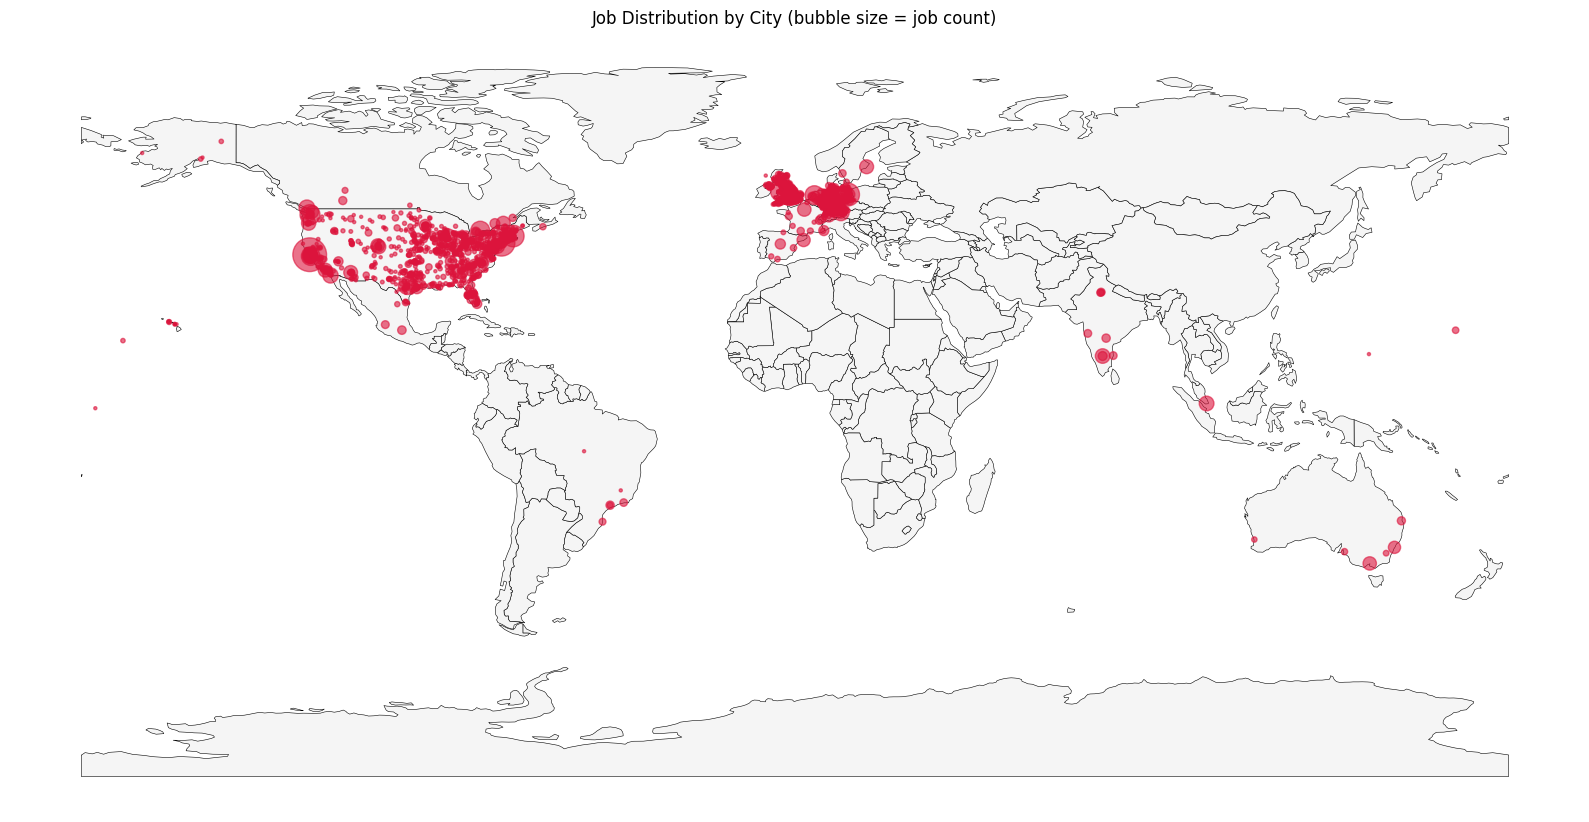

In [18]:
## World Map

coords = pd.read_csv("city_coordinates.csv")

df_geo = df[df["Country"] != "Remote"]
df_geo = df_geo.merge(coords, on=["City", "Country"], how="left")

city_counts = (
    df_geo
    .dropna(subset=["lat", "lon"])
    .groupby(["City", "Country", "lat", "lon"])
    .size()
    .reset_index(name="count")
)

world = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)
gdf_cities = gpd.GeoDataFrame(
    city_counts,
    geometry=gpd.points_from_xy(city_counts.lon, city_counts.lat),
    crs="EPSG:4326"
)


fig, ax = plt.subplots(figsize=(16, 10))
world.plot(ax=ax, color="#f5f5f5", edgecolor="black", linewidth=0.4)
sizes = np.sqrt(gdf_cities["count"]) * 5
gdf_cities.plot(
    ax=ax,
    markersize=sizes,
    color="crimson",
    alpha=0.6
)
ax.set_title("Job Distribution by City (bubble size = job count)")
ax.axis("off")
plt.tight_layout()
plt.show()
